# Quiz 3

BEFORE YOU START THIS QUIZ:

1. Click on "Copy to Drive" to make a copy of the quiz,

2. Click on "Share",
    
3. Click on "Change" and select "Anyone with this link can edit"
    
4. Click "Copy link" and

5. Paste the link into [this Canvas assignment](https://canvas.olin.edu/courses/390/assignments/6149).

DO THIS BEFORE YOU START THE QUIZ.

The following cells define functions we have used before.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
def values(series):
    """Count the values and sort.

    series: pd.Series

    returns: series mapping from values to frequencies
    """
    return series.value_counts().sort_index()

In [4]:
def decorate(**options):
    """Decorate the current axes.

    Call decorate with keyword arguments like
    decorate(title='Title',
             xlabel='x',
             ylabel='y')

    The keyword arguments can be any of the axis properties
    https://matplotlib.org/api/axes_api.html
    """
    ax = plt.gca()
    ax.set(**options)

    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(handles, labels)

    plt.tight_layout()

In [5]:
from statsmodels.nonparametric.smoothers_lowess import lowess


def make_lowess(series):
    """Use LOWESS to compute a smooth line.

    series: pd.Series

    returns: pd.Series
    """
    y = series.values
    x = series.index.values

    smooth = lowess(y, x)
    index, data = np.transpose(smooth)

    return pd.Series(data, index=index)

In [6]:
def plot_series_lowess(series, color="C0"):
    """Plots a series of data points and a smooth line.

    series: pd.Series
    color: string or tuple
    """
    series.plot(linewidth=0, marker="o", color=color, alpha=0.5)
    smooth = make_lowess(series)
    smooth.plot(label="_", color=color)

The following cell installs `empiricaldist` if needed.

In [7]:
try:
    import empiricaldist
except ImportError:
    !pip install empiricaldist

The following cell downloads the GSS data.

In [8]:
from os.path import basename, exists


def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve

        local, _ = urlretrieve(url, filename)
        print("Downloaded " + local)


download(
    "https://github.com/AllenDowney/PoliticalAlignmentCaseStudy/"
    + "raw/update2021/gss_eds.hdf5"
)

This data file contains the original data, which uses stratified sampling, so it is not a representative sample.

In [9]:
datafile = "gss_eds.hdf5"
gss = pd.read_hdf(datafile, "gss")
gss.shape

(68846, 204)

## The "Rise of the Nones"

During the last 20 years or so, the number of people who say they have no specific religious affiliation has increased substantially.
These people are often called "Nones" because when they are asked their religious preference, they choose "None".
In this notebook, we'll explore this so-called "Rise of the Nones".

In the GSS dataset, the variable `relig` records responses to the following question:

> What is your religious preference?  Is it Protestant, Catholic, Jewish, some other religion, or no religion?

You can read the [documentation of this variable here](https://gssdataexplorer.norc.org/variables/287/vshow).

The following cell selects this column from the GSS `DataFrame` and displays the distribution of the responses.

In [10]:
relig = gss["relig"]
values(relig)

1.0     38706
2.0     16498
3.0      1360
4.0      8918
5.0      1141
6.0       245
7.0       130
8.0        41
9.0       178
10.0      155
11.0      915
12.0       34
13.0      155
Name: relig, dtype: int64

**Question 1:** Before we go on, it is a good idea to check how many values are missing.
Use `isna` to check which values in `relig` are `NaN`, and display the total number of missing values.

In [11]:
# Solution

relig.isna().sum()

370

**Question 2:** Let's also spot-check the data to make sure it is consistent with the code book. Select only the rows from 1972 and use `values` to display the values of `relig` and how many times each one appears. 

Add a comment to indicate whether the results are  [consistent with the code book](https://gssdataexplorer.norc.org/variables/287/vshow).

In [12]:
# Solution

is_1972 = gss["year"] == 1972
values(relig[is_1972])

1.0    1031
2.0     413
3.0      54
4.0      83
5.0      27
Name: relig, dtype: int64

**Question 3**: Use the `empiricaldist` library to create a `Pmf` object that represents the distribution of religious preferences (for all years, not just 1972).

In [13]:
# Solution

from empiricaldist import Pmf

pmf_relig = Pmf.from_seq(relig)
pmf_relig

,probs
1.0,0.565249
2.0,0.240931
3.0,0.019861
4.0,0.130235
5.0,0.016663
6.0,0.003578
7.0,0.001898
8.0,0.000599
9.0,0.002599
10.0,0.002264


**Question 4:** Make a bar chart that shows the quantities in the `Pmf` on the x-axis and the fraction of people who reported each preference on the y-axis. 

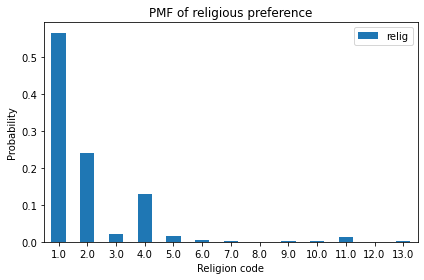

In [14]:
# Solution

pmf_relig.bar()

decorate(
    xlabel="Religion code", ylabel="Probability", title="PMF of religious preference"
)

**Question 5:** On the previous graph, add appropriate labels for the x- and y-axis, and give the whole graph an appropriate title.
You can use my `decorate` function or call Pyplot functions directly, whichever you prefer.

**Question 6:** One problem with the previous figure is that it is hard to see some of the small bars. In the next cell, make a version of the same figure that where the y-axis is on a logarithmic scale.

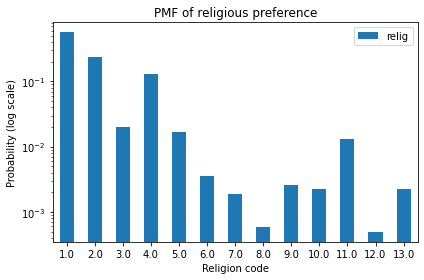

In [15]:
# Solution

pmf_relig.bar()

decorate(
    xlabel="Religion code",
    ylabel="Probability (log scale)",
    yscale="log",
    title="PMF of religious preference",
)

You can ignore the following empty cells.

In [16]:
# Solution

relig_map = {
    1: "Protestant",
    2: "Catholic",
    3: "Jewish",
    4: "None",
    5: "Other",
    6: "Buddhism",
    7: "Hinduism",
    8: "Other eastern religions",
    9: "Muslim/islam",
    10: "Orthodox-christian",
    11: "Christian",
    12: "Native american",
    13: "Inter-nondenominational",
}

In [17]:
# Solution

pmf_relig2 = Pmf.from_seq(relig.replace(relig_map)).sort_values() * 100
pmf_relig2

Native american             0.049652
Other eastern religions     0.059875
Hinduism                    0.189848
Inter-nondenominational     0.226357
Orthodox-christian          0.226357
Muslim/islam                0.259945
Buddhism                    0.357790
Christian                   1.336235
Other                       1.666277
Jewish                      1.986097
None                       13.023541
Catholic                   24.093113
Protestant                 56.524914
Name: relig, dtype: float64

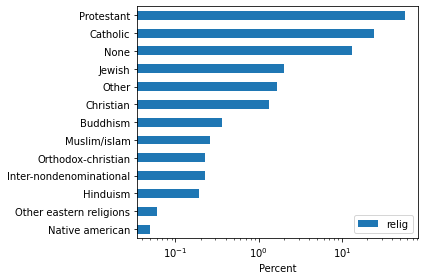

In [126]:
# Solution

pmf_relig2.plot(kind="barh")

decorate(xlabel="Percent", xscale='log')

## Fraction of "Nones" over time

Now let's see how the fraction of "Nones" has changed over time.

**Question 7:** Add a new column named `none` to the GSS `DataFrame`; it should be a Boolean Series that is `True` where `relig` equals 4 and `False` otherwise.

In [127]:
# Solution

gss["none"] = (gss["relig"] == 4)

You can use the following cell to check whether it worked.
The value `True` should appear 8918 times. 

In [20]:
values(gss["none"])

False    59928
True      8918
Name: none, dtype: int64

**Question 8:** Use `groupby` to group the GSS DataFrame by year.
Then select the `none` column from the resulting `GroupBy` object and compute its mean.
The result should be a `Series` that contains years as labels in the index and the fraction of "Nones" as values.

In [21]:
# Solution

gss_by_year = gss.groupby("year")

In [22]:
# Solution

none_by_year = gss_by_year["none"].mean()

You can use the following cell to plot the results.

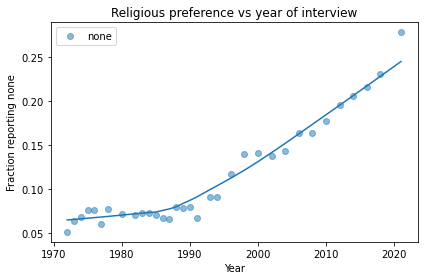

In [23]:
plot_series_lowess(none_by_year)

decorate(
    xlabel="Year",
    ylabel="Fraction reporting none",
    title="Religious preference vs year of interview",
)

## Group By Age

The following cells create a new column called `age10` that puts people into 10-year age groups. You don't need to understand all of the details.

In [24]:
bins = np.arange(17, 100, 10)
bins

array([17, 27, 37, 47, 57, 67, 77, 87, 97])

In [25]:
labels = bins[:-1] + 5
labels

array([22, 32, 42, 52, 62, 72, 82, 92])

In [26]:
gss["age10"] = pd.cut(gss["age"], bins, labels=labels).astype(float)

Here are the values of `age10` and the number of times each one appears.

In [27]:
values(gss["age10"])

22.0    10923
32.0    14528
42.0    12651
52.0    10879
62.0     9207
72.0     6586
82.0     2995
92.0      516
Name: age10, dtype: int64

The following figure shows the fraction of Nones in each age group.

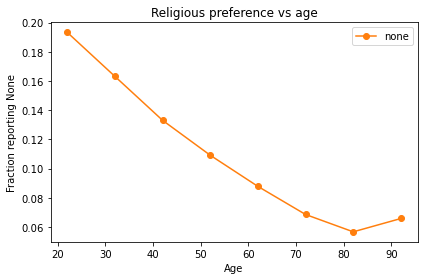

In [28]:
gss.groupby("age10")["none"].mean().plot(style="-o", color="C1")

decorate(
    xlabel="Age", ylabel="Fraction reporting None", title="Religious preference vs age"
)

## Group by Cohort

The column `cohort` contains year each respondent was born, so-called because all of the people born in the same period of time belong to the same "birth cohort".

The following cells create a new column called `cohort10` that puts people into 10-year birth cohorts.

In [29]:
bins = np.arange(1885, 2021, 10)
bins

array([1885, 1895, 1905, 1915, 1925, 1935, 1945, 1955, 1965, 1975, 1985,
       1995, 2005, 2015])

In [30]:
labels = bins[:-1] + 5
labels

array([1890, 1900, 1910, 1920, 1930, 1940, 1950, 1960, 1970, 1980, 1990,
       2000, 2010])

In [31]:
gss["cohort10"] = pd.cut(gss["cohort"], bins, labels=labels).astype(float)

Here are the value of `cohort10` and the number of times each one appears.

In [32]:
values(gss["cohort10"])

1890.0      283
1900.0     1378
1910.0     3213
1920.0     5472
1930.0     6570
1940.0     8980
1950.0    13594
1960.0    12636
1970.0     8011
1980.0     5276
1990.0     2452
2000.0      408
Name: cohort10, dtype: int64

The following figure shows the fraction of Nones in each age group.

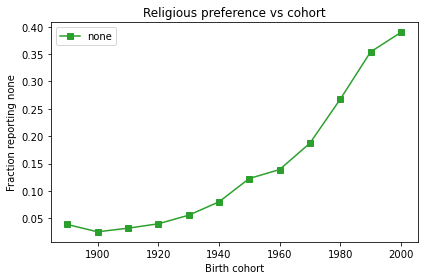

In [33]:
gss.groupby("cohort10")["none"].mean().plot(style="-s", color="C2")

decorate(
    xlabel="Birth cohort",
    ylabel="Fraction reporting none",
    title="Religious preference vs cohort",
)

**Question 9:** Make a version of the previous figure that plots the line and markers using a color selected from any Seaborn palette. You can [read about palettes here](https://seaborn.pydata.org/tutorial/color_palettes.html).

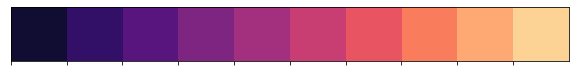

In [34]:
# Solution

palette = sns.color_palette("magma", 10)
sns.palplot(palette)

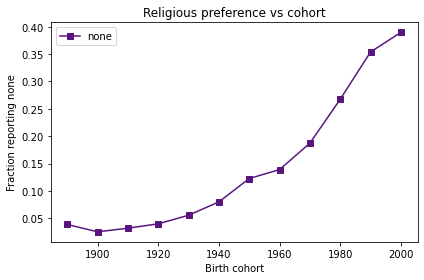

In [35]:
# Solution

gss.groupby("cohort10")["none"].mean().plot(style="-s", color=palette[2])

decorate(
    xlabel="Birth cohort",
    ylabel="Fraction reporting none",
    title="Religious preference vs cohort",
)

## Cross Tabulation

**Question 10:** Make a cross tabulation that has values of `cohort10` as labels in the index and values of `age10` as column names.
The values in the table should be the number of people in each cohort who were interviewed at each age.

In [36]:
# Solution

age = gss["age10"]
cohort = gss["cohort10"]

xtab = pd.crosstab(cohort, age)
xtab

age10,22.0,32.0,42.0,52.0,62.0,72.0,82.0,92.0
cohort10,,,,,,,,
1890.0,0,0,0,0,0,10,217,56
1900.0,0,0,0,0,13,768,492,105
1910.0,0,0,0,26,1203,1228,654,102
1920.0,0,0,30,1430,1794,1421,658,139
1930.0,0,18,1377,1702,1527,1229,613,104
1940.0,37,1737,2102,1928,1703,1115,358,0
1950.0,2009,3153,3022,2635,1960,815,0,0
1960.0,2640,3496,3130,2363,1007,0,0,0
1970.0,2160,2967,2089,795,0,0,0,0


You can use the following cell to plot the results (assuming you assign the cross tabulation to `xtab`).

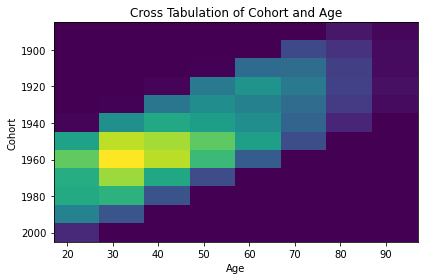

In [37]:
plt.pcolormesh(xtab.columns, xtab.index, xtab, shading="nearest")
plt.gca().invert_yaxis()

decorate(xlabel="Age", ylabel="Cohort", title="Cross Tabulation of Cohort and Age")

## Pivot Table

The following question is just for fun -- I won't grade it because we learned about pivot tables too recently.

**Question 11 Just for Fun:** Make a pivot table that has values of `age10` as labels in the index and values of `cohort10` as column names. The values in the pivot table should be the fraction of "Nones" in each age group and birth cohort.

In [38]:
# Solution

recent = gss["cohort10"] > 1930
subset = gss[recent]

In [39]:
# Solution

table = gss.pivot_table(
    values="none", index="age10", columns="cohort10", aggfunc="mean"
)

table

cohort10,1890.0,1900.0,1910.0,1920.0,1930.0,1940.0,1950.0,1960.0,1970.0,1980.0,1990.0,2000.0
age10,,,,,,,,,,,,
22.0,NaN,NaN,NaN,NaN,NaN,0.027027,0.130413,0.115909,0.161111,0.244946,0.333765,0.390663
32.0,NaN,NaN,NaN,NaN,0.111111,0.080023,0.093879,0.118707,0.185709,0.273577,0.388339,NaN
42.0,NaN,NaN,NaN,0.033333,0.052288,0.068982,0.112177,0.135463,0.204404,0.306326,NaN,NaN
52.0,NaN,NaN,0.038462,0.034965,0.039365,0.064315,0.132448,0.178587,0.220126,NaN,NaN,NaN
62.0,NaN,0.000000,0.029925,0.028986,0.054355,0.090429,0.149490,0.189672,NaN,NaN,NaN,NaN
72.0,0.100000,0.029948,0.030130,0.047854,0.068348,0.097758,0.159509,NaN,NaN,NaN,NaN,NaN
82.0,0.032258,0.020325,0.033639,0.056231,0.076672,0.131285,NaN,NaN,NaN,NaN,NaN,NaN
92.0,0.053571,0.019048,0.068627,0.079137,0.105769,NaN,NaN,NaN,NaN,NaN,NaN,NaN


You can use the following cell to plot the results.

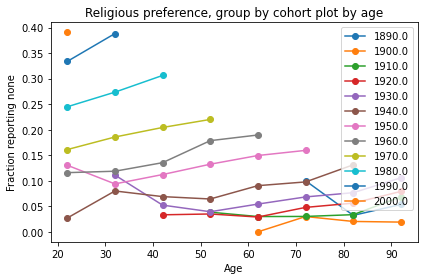

In [40]:
table.plot(style="-o")

decorate(
    xlabel="Age",
    ylabel="Fraction reporting none",
    title="Religious preference, group by cohort plot by age",
)

Ignore the following empty cells.

In [41]:
# Solution


def flip_legend():
    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(reversed(handles), reversed(labels))


def group_by_cohort_plot_by_age(gss):
    gss["none"] = gss["relig"] == 4

    bins = np.arange(1885, 2021, 10)
    labels = bins[:-1] + 5
    gss["cohort10"] = pd.cut(gss["cohort"], bins, labels=labels).astype(float)

    bins = np.arange(17, 100, 10)
    labels = bins[:-1] + 5
    gss["age10"] = pd.cut(gss["age"], bins, labels=labels).astype(float)

    recent = gss["cohort10"] > 1930
    subset = gss[recent]
    table = subset.pivot_table(
        values="none", index="age10", columns="cohort10", aggfunc="mean"
    )

    table.plot(style="-o")

    decorate(
        xlabel="Age",
        ylabel="Fraction reporting none",
        title="Religious preference, group by cohort plot by age",
    )

    flip_legend()

In [42]:
# Solution

download(
    "https://github.com/AllenDowney/PoliticalAlignmentCaseStudy/"
    + "raw/update2021/gss_eds.3.hdf5"
)

<Figure size 432x288 with 0 Axes>

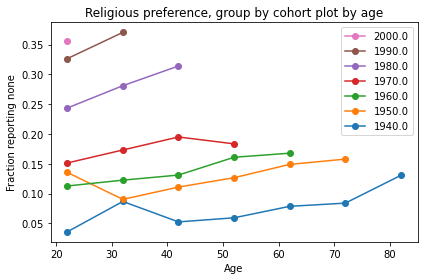

<Figure size 432x288 with 0 Axes>

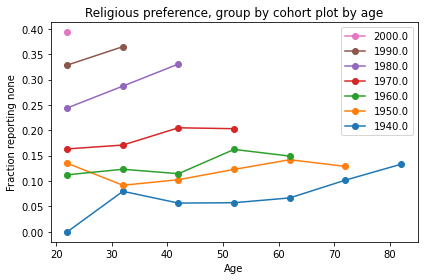

<Figure size 432x288 with 0 Axes>

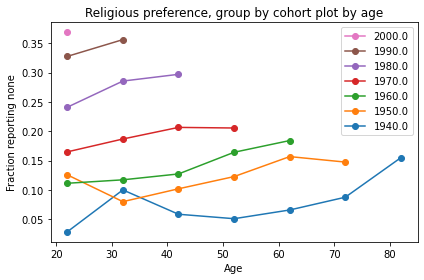

In [43]:
# Solution

for key in ["gss0", "gss1", "gss2"]:
    df = pd.read_hdf("gss_eds.3.hdf5", key)
    plt.figure()
    group_by_cohort_plot_by_age(df)

## Hexbin

`plt.hexbin` makes a graphical version of a cross tabulation.

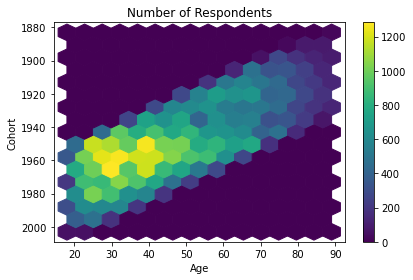

In [59]:
# Solution

plt.hexbin(x=gss['age'], y=gss['cohort'], gridsize=15)
plt.gca().invert_yaxis()
plt.colorbar()
decorate(xlabel='Age', ylabel='Cohort', title='Number of Respondents')

With a third parameter, it makes a graphical version of a pivot table.

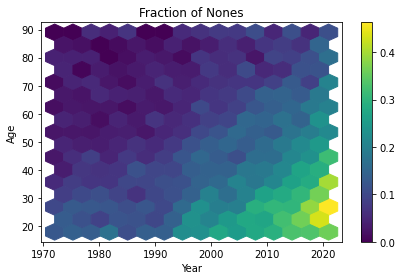

In [129]:
# Solution

plt.hexbin(x=gss['year'], y=gss['age'], 
           C=gss['none'], reduce_C_function=np.mean, 
           gridsize=15)
plt.colorbar()
decorate(xlabel='Year', ylabel='Age', title='Fraction of Nones')